# Análisis Exploratorio del Mercado Accionario Chileno

Análisis de precios históricos de 9 acciones del IPSA distribuidas en 5 sectores (Mayo 2024 – Mayo 2026).

| Sector | Acciones |
|---|---|
| Retail | FALABELLA, CENCOSUD |
| Energía | COPEC, ENELCHILE |
| Banca | BSANTANDER, BCI |
| Minería / Forestal | CAP, CMPC |
| Utilities | AGUAS-A |

Se calculan retornos acumulados, retornos diarios, estadística descriptiva, Sharpe ratio y matriz de correlación para caracterizar el comportamiento de cada activo y sector.

In [24]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np

## 1. Carga de datos

Descarga de precios históricos OHLCV via Yahoo Finance. Se aíslan los precios de cierre ajustados.

In [4]:
lista_nombre_acciones = ["COPEC.SN", "FALABELLA.SN", "CMPC.SN", "CENCOSUD.SN","ENELCHILE.SN", "BSANTANDER.SN", "BCI.SN","CAP.SN", "AGUAS-A.SN"]
datos_brutos_acciones = yf.download(tickers = lista_nombre_acciones, period = "2y")



[*********************100%***********************]  9 of 9 completed


In [5]:
datos_brutos_acciones.head()

Price            Close                                                        \
Ticker      AGUAS-A.SN        BCI.SN BSANTANDER.SN       CAP.SN  CENCOSUD.SN   
Date                                                                           
2024-05-15  244.372177  25617.787109     40.972973  6851.000000  1770.202881   
2024-05-16  244.499893  25263.626953     40.828449  6785.000000  1761.346924   
2024-05-17  245.029022  25853.898438     40.367771  6670.100098  1771.580566   
2024-05-20  248.459351  25613.064453     40.331642  6665.000000  1815.368164   
2024-05-22  249.061462  25499.734375     40.828449  6586.000000  1815.466553   

Price                                                                 High  \
Ticker          CMPC.SN     COPEC.SN ENELCHILE.SN FALABELLA.SN  AGUAS-A.SN   
Date                                                                         
2024-05-15  1888.693970  7226.271484    50.189449  2626.310303  246.315409   
2024-05-16  1893.750244  7137.905762    48.949059  2631.111328  245.859231   
2024-05-17  1933.308838  7313.654297    48.012432  2688.727051  245.412206   
2024-05-20  1913.479980  7242.274414    48.442776  2718.495117  249.928189   
2024-05-22  1898.608398  7481.546875    48.518715  2669.521973  249.973775   

Price       ...         Open     Volume                              \
Ticker      ... FALABELLA.SN AGUAS-A.SN BCI.SN BSANTANDER.SN CAP.SN   
Date        ...                                                       
2024-05-15  ...  2626.310303     357219  18876      60657812  50982   
2024-05-16  ...  2631.111328    2612021  36968      31498703  51281   
2024-05-17  ...  2688.727051     271900  19445      19245598  12258   
2024-05-20  ...  2718.495117      80759  16812       6945155  15883   
2024-05-22  ...  2669.521973     290759  17060      18779235  48101   

Price                                                              
Ticker     CENCOSUD.SN CMPC.SN COPEC.SN ENELCHILE.SN FALABELLA.SN  
Date                                                               
2024-05-15      341799  207898    46812      5292982       155806  
2024-05-16     1238867  363220   261439     10084716       294253  
2024-05-17      640811  744388   184210     11945645       310075  
2024-05-20      175417   98616    38906      2411038       159951  
2024-05-22      253585  539541   159421     13089720       463567  

[5 rows x 45 columns]

In [6]:
precios_cierre = datos_brutos_acciones["Close"]
precios_cierre

Ticker,AGUAS-A.SN,BCI.SN,BSANTANDER.SN,CAP.SN,CENCOSUD.SN,CMPC.SN,COPEC.SN,ENELCHILE.SN,FALABELLA.SN
Date,,,,,,,,,
2024-05-15,244.372177,25617.787109,40.972973,6851.000000,1770.202881,1888.693970,7226.271484,50.189449,2626.310303
2024-05-16,244.499893,25263.626953,40.828449,6785.000000,1761.346924,1893.750244,7137.905762,48.949059,2631.111328
2024-05-17,245.029022,25853.898438,40.367771,6670.100098,1771.580566,1933.308838,7313.654297,48.012432,2688.727051
2024-05-20,248.459351,25613.064453,40.331642,6665.000000,1815.368164,1913.479980,7242.274414,48.442776,2718.495117
2024-05-22,249.061462,25499.734375,40.828449,6586.000000,1815.466553,1898.608398,7481.546875,48.518715,2669.521973
...,...,...,...,...,...,...,...,...,...
2026-05-11,334.989990,58010.000000,66.750000,7170.000000,2115.000000,1143.599976,6190.000000,78.153976,5620.000000
2026-05-12,332.980011,57126.000000,68.260002,7005.600098,2055.100098,1110.000000,6180.000000,76.947899,5535.000000
2026-05-13,328.000000,55747.000000,67.489998,6730.000000,2083.100098,1100.000000,6143.500000,75.741814,5380.000000


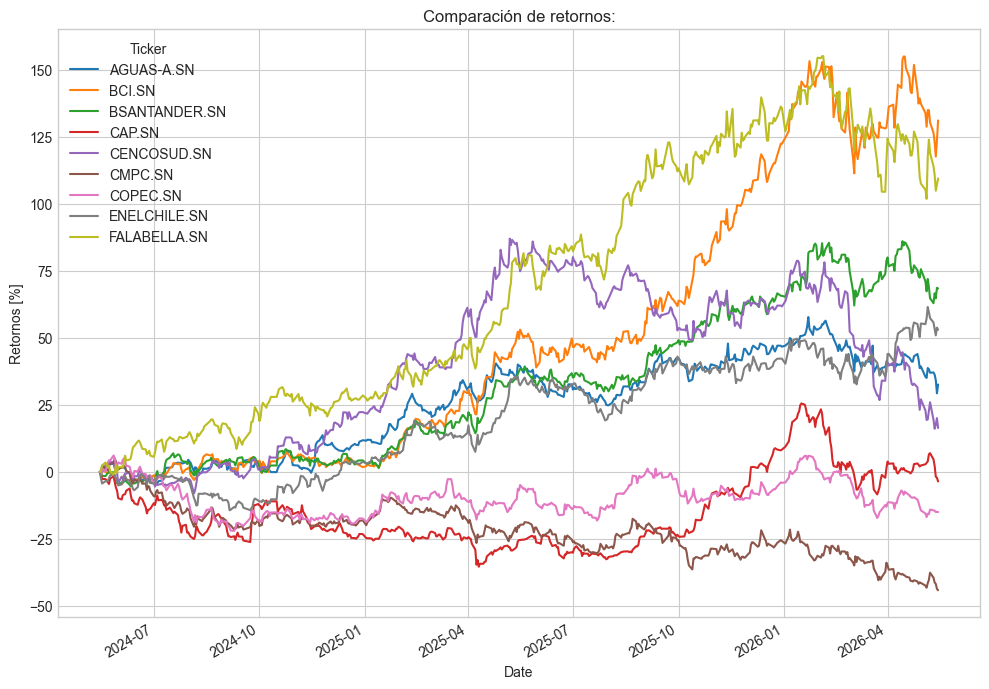

In [7]:
precios_normalizados = precios_cierre/precios_cierre.iloc[0]*100
retornos_en_tiempo = precios_normalizados - 100
plt.style.use('seaborn-v0_8-whitegrid')
fig, rt_g = plt.subplots(figsize=(10, 7))
rt_g.set_title('Comparación de retornos:')
rt_g.set_xlabel("Fecha")
rt_g.set_ylabel("Retornos [%]")
retornos_en_tiempo.plot(ax=rt_g)
plt.tight_layout()

## 2. Retornos totales y precios normalizados

Se calcula el retorno total de cada acción en el período y se normalizan los precios (base 100) para comparar rendimiento relativo en un mismo gráfico.

In [8]:
retornos_diarios = precios_cierre.pct_change()
retornos_diarios

Ticker,AGUAS-A.SN,BCI.SN,BSANTANDER.SN,CAP.SN,CENCOSUD.SN,CMPC.SN,COPEC.SN,ENELCHILE.SN,FALABELLA.SN
Date,,,,,,,,,
2024-05-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-16,0.000523,-0.013825,-0.003527,-0.009634,-0.005003,0.002677,-0.012228,-0.024714,0.001828
2024-05-17,0.002164,0.023364,-0.011283,-0.016934,0.005810,0.020889,0.024622,-0.019135,0.021898
2024-05-20,0.014000,-0.009315,-0.000895,-0.000765,0.024717,-0.010256,-0.009760,0.008963,0.011071
2024-05-22,0.002423,-0.004425,0.012318,-0.011853,0.000054,-0.007772,0.033038,0.001568,-0.018015
...,...,...,...,...,...,...,...,...,...
2026-05-11,0.000747,-0.016780,-0.011111,-0.021828,-0.051570,-0.029943,-0.003221,-0.010506,-0.022609
2026-05-12,-0.006000,-0.015239,0.022622,-0.022929,-0.028321,-0.029381,-0.001616,-0.015432,-0.015125
2026-05-13,-0.014956,-0.024140,-0.011280,-0.039340,0.013625,-0.009009,-0.005906,-0.015674,-0.028004


## 3. Retornos diarios y estadística descriptiva

Los retornos diarios se calculan con `pct_change()`. Se reportan: retorno promedio diario, volatilidad (desviación estándar) y Sharpe simplificado (retorno/volatilidad, sin tasa libre de riesgo).

In [9]:
sharpe = retornos_diarios.mean()/retornos_diarios.std()
media = retornos_diarios.mean()
dst = retornos_diarios.std()

pd.DataFrame({"Media" : media,"Desviación Estandar" : dst, "Ratio de Sharpe" : sharpe, "Porcentaje de Retorno" : retornos_en_tiempo.iloc[-1]}).sort_values("Porcentaje de Retorno", ascending = False)

,Media,Desviación Estandar,Ratio de Sharpe,Porcentaje de Retorno
Ticker,,,,
BCI.SN,0.001819,0.015878,0.114542,131.062112
FALABELLA.SN,0.001637,0.016892,0.096883,109.426898
BSANTANDER.SN,0.001132,0.012537,0.090253,68.379283
ENELCHILE.SN,0.000960,0.014187,0.067681,53.040128
AGUAS-A.SN,0.000645,0.012266,0.052581,32.584652
CENCOSUD.SN,0.000442,0.016487,0.026796,16.370842
CAP.SN,0.000064,0.016596,0.003870,-3.554226
COPEC.SN,-0.000215,0.014986,-0.014375,-14.963062
CMPC.SN,-0.001028,0.017233,-0.059647,-44.141295


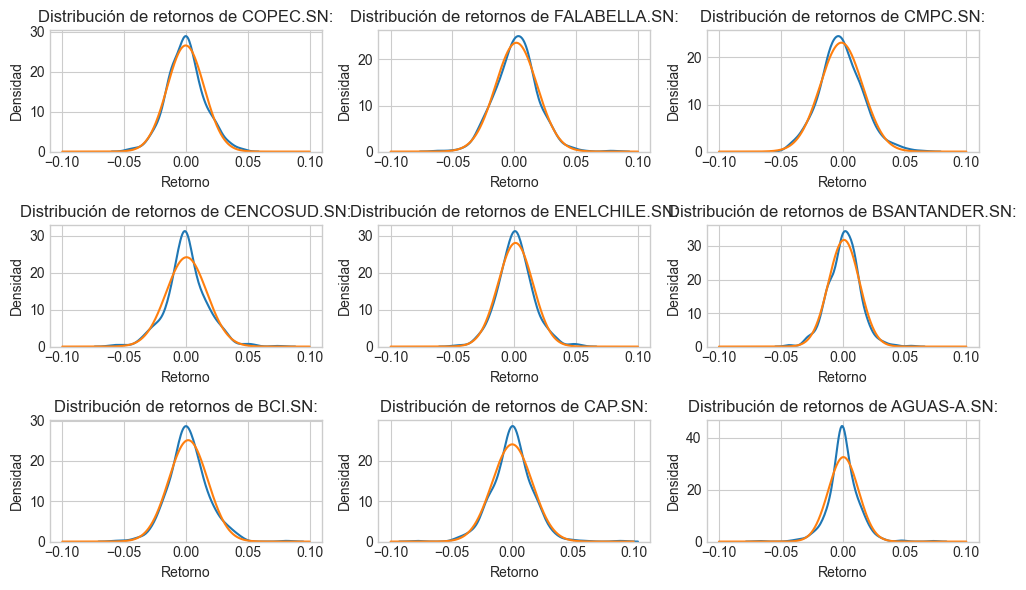

In [29]:
fig, gauss_retornos = plt.subplots(3, 3, figsize=(10, 6))
x = 0
y = 0

for i in lista_nombre_acciones:
    x_valores = np.linspace(-0.1, 0.1, 1000)
    densidad_normal = norm.pdf(x_valores, loc=media[i], scale=dst[i])
    sns.kdeplot(retornos_diarios[i], ax = gauss_retornos[x][y])
    gauss_retornos[x][y].set_title("Distribución de retornos de " + i + ":")
    gauss_retornos[x][y].set_ylabel("Densidad")
    gauss_retornos[x][y].set_xlabel("Retorno")
    plt.tight_layout()
    gauss_retornos[x][y].plot(x_valores, densidad_normal)
    if y == 2:
        y = 0
        x += 1
    else:
        y += 1


## 4. Matriz de correlación

La correlación entre retornos diarios mide qué tan relacionados están los movimientos de precio entre pares de activos. Valores cercanos a 1 indican que se mueven juntos; cercanos a 0, independencia.

<Axes: xlabel='Ticker', ylabel='Ticker'>

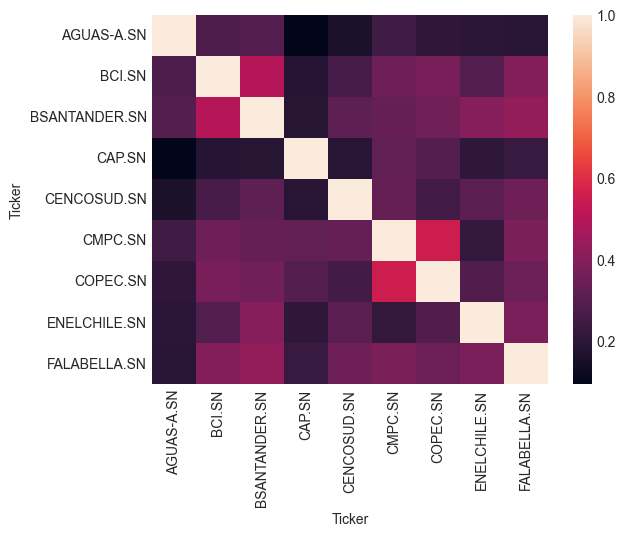

In [ ]:
sns.heatmap(retornos_diarios.corr())